In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_sample_weight

In [5]:
df = pd.read_csv("/home/jithesh/Desktop/food_suitability_bot/data/processed/labeled_dataset.csv")
df.head()

,age,condition,food_name,calories,protein_g,fat_g,carbs_g,sugar_g,fiber_g,sodium_mg,gi_value,label
0,58,diabetes,"semolina, unenriched",360.0,12.68,1.05,72.83,0.00,3.9,1.0,50,safe
1,19,kidney_disease,"waxgourd, (chinese preserving melon), raw",13.0,0.40,0.20,3.00,0.00,2.9,111.0,50,safe
2,33,hypertension,"wheat flour, white (industrial), 13% protein, ...",362.0,13.07,1.38,72.20,1.10,2.4,2.0,50,safe
3,26,diabetes,"babyfood, fruit, pears, strained",42.0,0.30,0.20,10.80,6.98,2.8,1.0,50,safe
4,61,diabetes,"mother's loaf, pork",282.0,12.07,22.30,7.53,0.00,0.0,1127.0,50,moderate


In [7]:
df.shape

(8000, 12)

In [8]:
condition_encoder = LabelEncoder()
df['condition_enc'] = condition_encoder.fit_transform(df['condition'])
print(f"\nConditions encoded: {dict(zip(condition_encoder.classes_, condition_encoder.transform(condition_encoder.classes_)))}")


Conditions encoded: {'diabetes': 0, 'healthy': 1, 'hypertension': 2, 'kidney_disease': 3}


In [9]:
# Training Features
FEATURE_COLS = [
    'age', 'condition_enc',
    'calories', 'protein_g', 'fat_g', 'carbs_g',
    'sugar_g', 'fiber_g', 'sodium_mg', 'gi_value'
]

In [10]:
X = df[FEATURE_COLS]
y = df['label']

In [11]:
# Encode target label
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")



Train size: 6400, Test size: 1600


In [14]:
# Handles class imbalance — gives more weight to minority classes

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [ ]:
# Model Training - XGBoost

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred = model.predict(X_test)

In [17]:
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

       avoid       0.98      0.96      0.97       184
    moderate       0.99      0.99      0.99       682
        safe       1.00      1.00      1.00       734

    accuracy                           0.99      1600
   macro avg       0.99      0.98      0.99      1600
weighted avg       0.99      0.99      0.99      1600



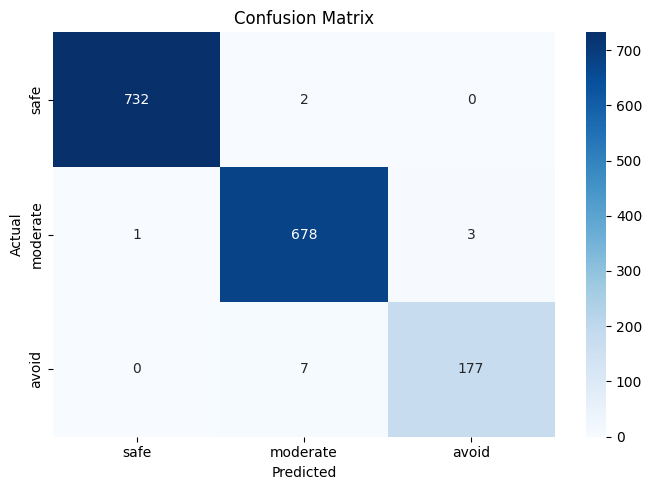

In [19]:
cm = confusion_matrix(y_test_labels, y_pred_labels,
                       labels=['safe','moderate','avoid'])
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['safe','moderate','avoid'],
            yticklabels=['safe','moderate','avoid'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()

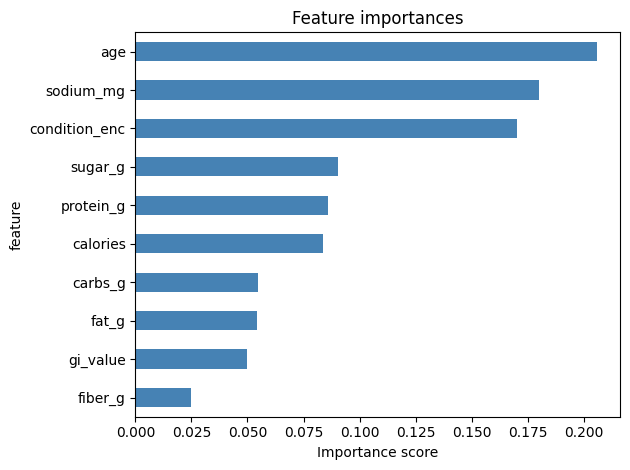

In [20]:
importances = model.feature_importances_
feat_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=True)

feat_df.plot(kind='barh', x='feature', y='importance',
             legend=False, color='steelblue')
plt.title("Feature importances")
plt.xlabel("Importance score")
plt.tight_layout()

In [21]:
print("\nRunning 5-fold cross-validation...")
cv_scores = cross_val_score(model, X, y_enc, cv=5, scoring='f1_macro')
print(f"CV F1 scores: {cv_scores.round(3)}")
print(f"Mean CV F1:   {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


Running 5-fold cross-validation...
CV F1 scores: [0.991 0.977 0.99  0.99  0.976]
Mean CV F1:   0.985 (+/- 0.007)
